In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

df = pd.read_csv("vinhos_dataset.csv")

In [4]:
# Inspecionando dataset original
df.shape

(6497, 13)

In [5]:
print(df["color"].value_counts())

color
white    4898
red      1599
Name: count, dtype: int64


In [43]:
print(df["quality"].value_counts())

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64


In [6]:
# Inspecionando dataset original
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [7]:
from pathlib import Path

# Caminho do arquivo original
arquivo_original = Path("vinhos_dataset.csv")

# Converter color para numérico
df['color'] = df['color'].map({
    'red': 0,
    'white': 1
})

# Criar o nome do novo arquivo no mesmo diretório
arquivo_novo = arquivo_original.parent / "vinhos_dataset_color_num.csv"

# Salvar o novo arquivo
df.to_csv(arquivo_novo, index=False)

print("Arquivo salvo em:")
print(arquivo_novo)

Arquivo salvo em:
vinhos_dataset_color_num.csv


In [8]:
# Inspecionando apos mudar variavel color para numerica

df_color = pd.read_csv("vinhos_dataset_color_num.csv")

df_color.shape

(6497, 13)

In [9]:
# Inspecionando apos mudar variavel color para numerica
df_color.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [10]:
# Encontrando dados duplicados
df_color.duplicated().sum()

np.int64(1177)

In [11]:
df_color[df_color.duplicated()]

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5,0
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5,0
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,5,0
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.500000,5,0
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.900000,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6427,6.4,0.230,0.35,10.30,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5,1
6449,7.0,0.360,0.35,2.50,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6,1
6450,6.4,0.330,0.44,8.90,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5,1
6455,7.1,0.230,0.39,13.70,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6,1


In [12]:
# Carregar o dataset com color já convertido para numérico
df_color = pd.read_csv("vinhos_dataset_color_num.csv")

# Remover duplicados e resetar o índice
df_cleaned = df_color.drop_duplicates().reset_index(drop=True)

# Salvar o dataset limpo com color numérico
df_cleaned.to_csv(
    "vinhos_dataset_cleaned.csv",
    index=False
)

# Definir as variáveis que serão utilizadas
features = [
    'fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'color'
]

print("Arquivo salvo: vinhos_dataset_cleaned.csv")
print("\nValores de color:")
print(df_cleaned["color"].value_counts())

Arquivo salvo: vinhos_dataset_cleaned.csv

Valores de color:
color
1    3961
0    1359
Name: count, dtype: int64


In [13]:
# Carrega df sem duplicados
df_cleaned = pd.read_csv("vinhos_dataset_cleaned.csv")

df_cleaned.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0


In [14]:
# Checar se as linhas foram removidas
df_cleaned.shape

(5320, 13)

In [15]:
# Carregar o arquivo original (apos remocao de duplicados)
df_cleaned = pd.read_csv('vinhos_dataset_cleaned.csv')

# Criar os componentes principais (PCA)
pca_acidity = PCA(n_components=1)
df_cleaned['combined_acidity'] = pca_acidity.fit_transform(df_cleaned[['fixed_acidity', 'volatile_acidity']])

pca_so2 = PCA(n_components=1)
df_cleaned['combined_sulfur_dioxide'] = pca_so2.fit_transform(df_cleaned[['free_sulfur_dioxide', 'total_sulfur_dioxide']])

# Criar uma nova versão sem as 4 colunas originais
df_reduced = df_cleaned.drop(columns=[
    'fixed_acidity', 
    'volatile_acidity', 
    'free_sulfur_dioxide', 
    'total_sulfur_dioxide'
])

# 4. Salvar em um NOVO arquivo na mesma pasta (sem sobrescrever o original)
nome_novo_arquivo = 'vinhos_dataset_reduced.csv'
df_reduced.to_csv(nome_novo_arquivo, index=False)

In [16]:
# Carregar o arquivo reduzido (apos remocao de duplicados e combinadas as 4 colunas - reducao de dimensionalidade)
df_reduced = pd.read_csv('vinhos_dataset_reduced.csv')

# verificando a dl sem duplicados
df_reduced[df_reduced.duplicated()]


,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide


In [17]:
# Checar se as linhas foram removidas
df_reduced.shape

(5320, 11)

In [18]:
# Checar se as linhas foram removidas
df_reduced.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5,0,0.194643,-82.339801
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5,0,0.599492,-47.003146
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5,0,0.596156,-61.956149
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6,0,3.981499,-55.656877
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,5,0,0.193531,-76.040530


In [19]:
df_reduced.columns

Index(['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'quality', 'color', 'combined_acidity',
       'combined_sulfur_dioxide'],
      dtype='str')

In [20]:
df_reduced.shape

(5320, 11)

In [21]:
df_reduced.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5,0,0.194643,-82.339801
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5,0,0.599492,-47.003146
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5,0,0.596156,-61.956149
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6,0,3.981499,-55.656877
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,5,0,0.193531,-76.040530


In [22]:
from sklearn.ensemble import IsolationForest

# Definir APENAS as variáveis numéricas que devem ser padronizadas (depois da reducao de dimensionalidade)
features_sem_outliers = [
    'citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'quality', 'color', 'combined_acidity',
       'combined_sulfur_dioxide'
]

# Variáveis usadas
X = df_reduced[features_sem_outliers]

# Identificar outliers nos dados originais
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

outlier_labels = iso.fit_predict(X)

# 1 = normal
# -1 = outlier
mask = outlier_labels == 1

# Criar DataFrame sem outliers
df_sem_outliers = df_reduced.loc[mask].copy()

# Salvar novo arquivo
df_sem_outliers.to_csv(
    "vinhos_dataset_sem_outliers.csv",
    index=False
)

print("Dados originais:", len(df_reduced))
print("Dados sem outliers:", len(df_sem_outliers))
print("Outliers removidos:", sum(outlier_labels == -1))

Dados originais: 5320
Dados sem outliers: 5266
Outliers removidos: 54


In [23]:
# Insecionando para ver se outliers foram removidos
df_sem_outliers.shape

(5266, 11)

In [24]:
df_sem_outliers.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
0,0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5,0,0.194643,-82.339801
1,0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5,0,0.599492,-47.003146
2,0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5,0,0.596156,-61.956149
3,0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6,0,3.981499,-55.656877
4,0.00,1.8,0.075,0.9978,3.51,0.56,9.4,5,0,0.193531,-76.040530


In [25]:
df_sem_outliers.columns

Index(['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'quality', 'color', 'combined_acidity',
       'combined_sulfur_dioxide'],
      dtype='str')

In [26]:
df_sem_outliers.dtypes

citric_acid                float64
residual_sugar             float64
chlorides                  float64
density                    float64
pH                         float64
sulphates                  float64
alcohol                    float64
quality                      int64
color                        int64
combined_acidity           float64
combined_sulfur_dioxide    float64
dtype: object

In [27]:
df_sem_outliers.info()

<class 'pandas.DataFrame'>
Index: 5266 entries, 0 to 5319
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   citric_acid              5266 non-null   float64
 1   residual_sugar           5266 non-null   float64
 2   chlorides                5266 non-null   float64
 3   density                  5266 non-null   float64
 4   pH                       5266 non-null   float64
 5   sulphates                5266 non-null   float64
 6   alcohol                  5266 non-null   float64
 7   quality                  5266 non-null   int64  
 8   color                    5266 non-null   int64  
 9   combined_acidity         5266 non-null   float64
 10  combined_sulfur_dioxide  5266 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 493.7 KB


In [28]:
df_sem_outliers.describe()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
count,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000
mean,0.316622,5.042186,0.054947,0.994488,3.225602,0.529033,10.551873,5.798709,0.751234,-0.023857,0.503913
std,0.144908,4.422816,0.028413,0.002876,0.159339,0.140801,1.179272,0.874524,0.432339,1.276119,58.082257
min,0.000000,0.600000,0.009000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000,-3.414807,-111.429443
25%,0.240000,1.800000,0.038000,0.992200,3.120000,0.430000,9.500000,5.000000,1.000000,-0.817202,-39.573962
50%,0.310000,2.700000,0.047000,0.994600,3.220000,0.510000,10.400000,6.000000,1.000000,-0.306484,2.281590
75%,0.390000,7.500000,0.065000,0.996700,3.330000,0.600000,11.400000,6.000000,1.000000,0.482851,41.418991
max,1.660000,31.600000,0.346000,1.010300,4.010000,1.980000,14.200000,9.000000,1.000000,7.778084,376.755674


In [29]:
df_sem_outliers.describe(include="all")

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
count,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000,5266.000000
mean,0.316622,5.042186,0.054947,0.994488,3.225602,0.529033,10.551873,5.798709,0.751234,-0.023857,0.503913
std,0.144908,4.422816,0.028413,0.002876,0.159339,0.140801,1.179272,0.874524,0.432339,1.276119,58.082257
min,0.000000,0.600000,0.009000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000,-3.414807,-111.429443
25%,0.240000,1.800000,0.038000,0.992200,3.120000,0.430000,9.500000,5.000000,1.000000,-0.817202,-39.573962
50%,0.310000,2.700000,0.047000,0.994600,3.220000,0.510000,10.400000,6.000000,1.000000,-0.306484,2.281590
75%,0.390000,7.500000,0.065000,0.996700,3.330000,0.600000,11.400000,6.000000,1.000000,0.482851,41.418991
max,1.660000,31.600000,0.346000,1.010300,4.010000,1.980000,14.200000,9.000000,1.000000,7.778084,376.755674


In [30]:
df_sem_outliers.isnull().sum()

citric_acid                0
residual_sugar             0
chlorides                  0
density                    0
pH                         0
sulphates                  0
alcohol                    0
quality                    0
color                      0
combined_acidity           0
combined_sulfur_dioxide    0
dtype: int64

In [31]:
df_sem_outliers.isnull().mean() * 100

citric_acid                0.0
residual_sugar             0.0
chlorides                  0.0
density                    0.0
pH                         0.0
sulphates                  0.0
alcohol                    0.0
quality                    0.0
color                      0.0
combined_acidity           0.0
combined_sulfur_dioxide    0.0
dtype: float64

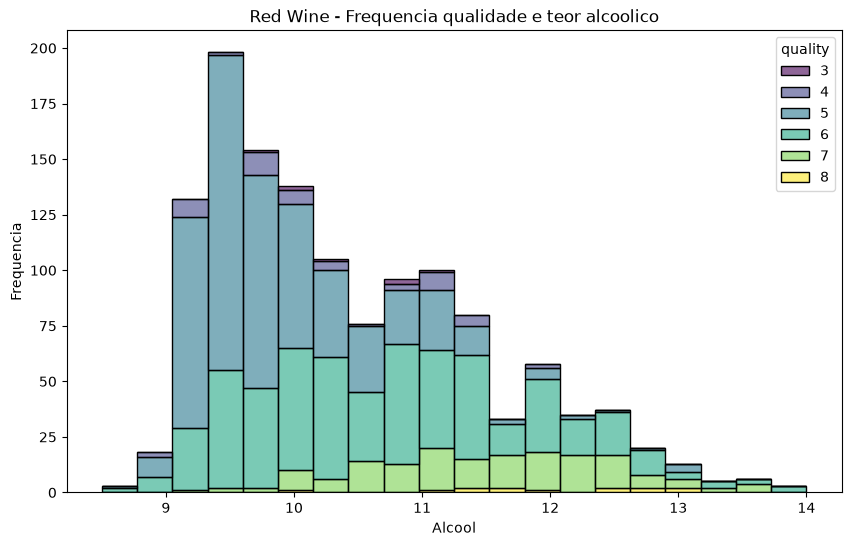

In [32]:

# Grafico de frequencia dequalidade e teor alcoolico red wine
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_sem_outliers[df_sem_outliers['color'] == 0],
    x='alcohol',
    hue='quality',
     palette="viridis",
    multiple='stack',
    bins=20,
    alpha=0.6
)

plt.title('Red Wine - Frequencia qualidade e teor alcoolico')
plt.xlabel('Alcool')
plt.ylabel('Frequencia')
plt.show()

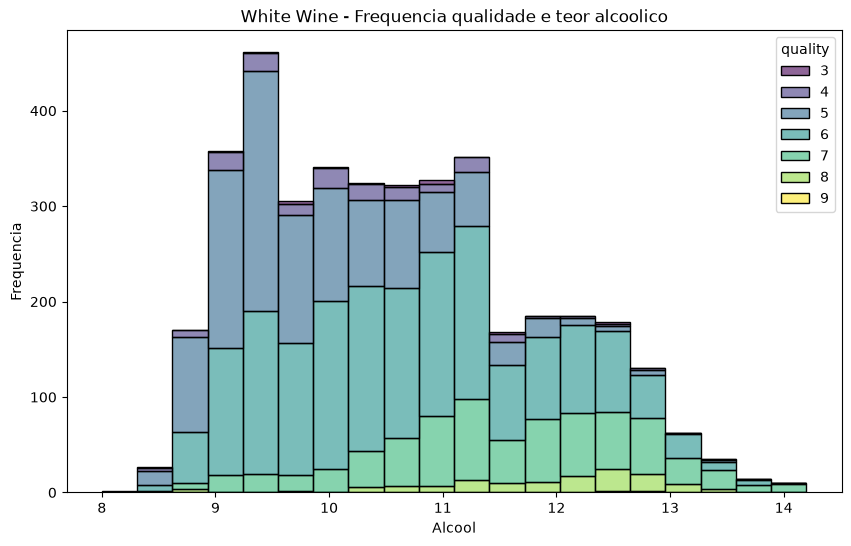

In [33]:
# Grafico de qualidade por teor alcoolico white wine
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_sem_outliers[df_sem_outliers['color'] == 1],
    x='alcohol',
    hue='quality',
    palette="viridis",
    multiple='stack',
    bins=20,
    alpha=0.6
)

plt.title('White Wine - Frequencia qualidade e teor alcoolico')
plt.xlabel('Alcool')
plt.ylabel('Frequencia')
plt.show()

In [34]:
df_sem_outliers["color"].map({
    0: "red",
    1: "white"
}).value_counts()

color
white    3956
red      1310
Name: count, dtype: int64

In [35]:
df_sem_outliers["color"].map({
    0: "red",
    1: "white"
}).value_counts(normalize=True) * 100

color
white    75.123433
red      24.876567
Name: proportion, dtype: float64

In [36]:
df_sem_outliers["quality"].value_counts()

quality
6    2312
5    1729
7     848
4     202
8     144
3      26
9       5
Name: count, dtype: int64

In [37]:
df_sem_outliers["quality"].value_counts(normalize=True) * 100

quality
6    43.904292
5    32.833270
7    16.103304
4     3.835929
8     2.734523
3     0.493733
9     0.094949
Name: proportion, dtype: float64

In [38]:
from sklearn.preprocessing import StandardScaler

In [42]:
# Nao altera ainda (scaler) color para que eu possa contar vinhos red e white depois de remover duplicados, outliers, etc
features = [
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'quality'
]

scaler = StandardScaler()

df_sem_outliers[features] = scaler.fit_transform(
    df_sem_outliers[features]
)

df_sem_outliers["color"].map({
    0: "red",
    1: "white"
}).value_counts(normalize=True) * 100

df_sem_outliers["color"].map({
    0: "red",
    1: "white"
}).value_counts(normalize=True) * 100

Series([], Name: proportion, dtype: float64)

In [39]:
# Quais colunas para "scale" (Novas colunas criadas de acidity e sulfor ja estao em escala)
features = [
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'density',
    'pH',
    'sulphates',
    'alcohol' , 
    'quality' ,
    'color'
]

# Criado o scaler
scaler = StandardScaler()

# Scale calcula a media e o desvio padrao de cada "feature" e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
df_sem_outliers[features] = scaler.fit_transform(df_sem_outliers[features])

# Mostra as colunas com dados estatisticos basicos
df_sem_outliers.describe(include="all")

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
count,5.266000e+03,5.266000e+03,5.266000e+03,5.266000e+03,5.266000e+03,5.266000e+03,5.266000e+03,5.266000e+03,5.266000e+03,5266.000000,5266.000000
mean,7.556094e-17,-6.476652e-17,4.317768e-17,1.465882e-14,3.238326e-16,-1.295330e-16,1.176592e-15,-1.295330e-16,1.295330e-16,-0.023857,0.503913
std,1.000095e+00,1.000095e+00,1.000095e+00,1.000095e+00,1.000095e+00,1.000095e+00,1.000095e+00,1.000095e+00,1.000095e+00,1.276119,58.082257
min,-2.185190e+00,-1.004475e+00,-1.617230e+00,-2.565727e+00,-3.173414e+00,-2.195027e+00,-2.164144e+00,-3.200569e+00,-1.737771e+00,-3.414807,-111.429443
25%,-5.288109e-01,-7.331288e-01,-5.964879e-01,-7.956516e-01,-6.628115e-01,-7.034223e-01,-8.920525e-01,-9.133935e-01,5.754499e-01,-0.817202,-39.573962
50%,-4.570036e-02,-5.296192e-01,-2.797058e-01,3.896170e-02,-3.516084e-02,-1.351921e-01,-1.287976e-01,2.301943e-01,5.754499e-01,-0.306484,2.281590
75%,5.064260e-01,5.557654e-01,3.538583e-01,7.692483e-01,6.552549e-01,5.040669e-01,7.192635e-01,2.301943e-01,5.754499e-01,0.482851,41.418991
max,9.271432e+00,6.005300e+00,1.024450e+01,5.498724e+00,4.923280e+00,1.030604e+01,3.093834e+00,3.660958e+00,5.754499e-01,7.778084,376.755674
